# Comparison of bed output of rastair and rastair2

Let's load data and check if the two agree

In [76]:
suppressPackageStartupMessages({
    library("data.table")
    library("ggplot2")
    library("ggVennDiagram")
    library("rtracklayer")
    library("Biostrings")
})

params <- list(threads = 8,
               rastair1 = "../../rastair/target/release/rastair",
               rastair2 = "../target/release/rastair2",
               test_fasta = "../tests/data/test.fasta.gz",
               test_bam = "../tests/data/test.bam")

First, we run rastair 1 and load the output directly:

In [20]:
rastair.1 <- fread(cmd=paste0(params$rastair1, " call -F 3852 -q 0 -Q 1 -l chr19 -r ", params$test_fasta, " ", params$test_bam), header=TRUE, stringsAsFactors=TRUE)
setnames(rastair.1, 1, "chr")

Next, we need to run rastair 2 and demand bed output, then parse this:

In [25]:
outfile <- tempfile(fileext=".bed")
system(paste(params$rastair2, "call -l chr19 --cpgs-only -F 3852 --bed", outfile, "-r", params$test_fasta, params$test_bam))

In [26]:
rastair.2 <- fread(outfile, header=TRUE, stringsAsFactors=TRUE)
setnames(rastair.2, 1, "chr")
unlink(outfile)

In [23]:
dim(rastair.2)

[1] 1303   14

In [24]:
dim(rastair.1)

[1] 1448   14

Some differences... Let's look at the distribution of values

[1] 961   5

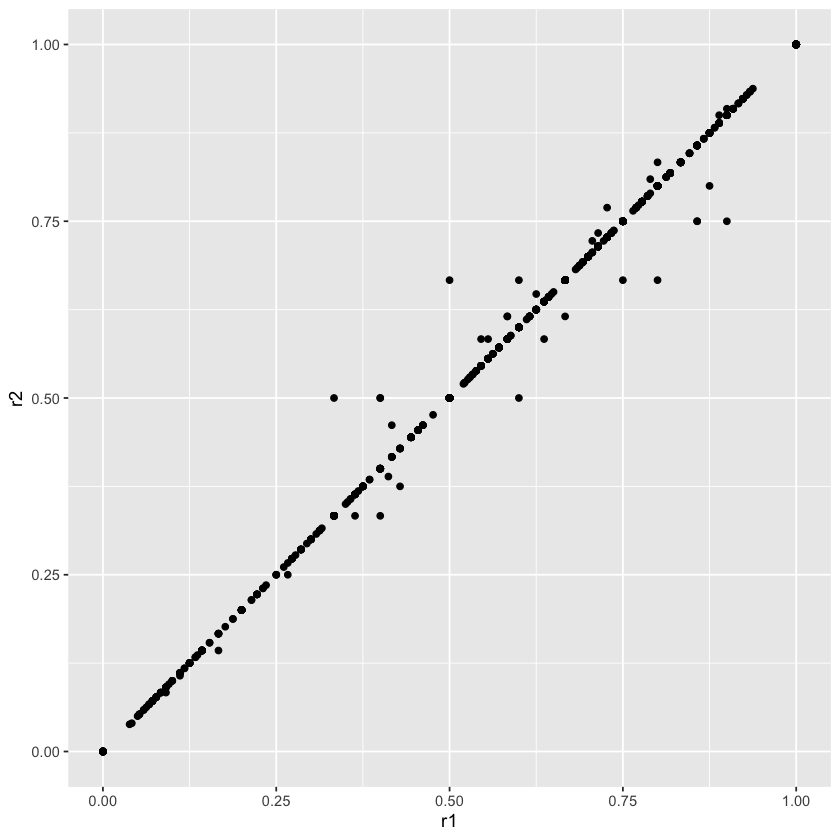

In [32]:
setkey(rastair.1, chr, start, end)
setkey(rastair.2, chr, start, end)
r1_vs_r2 <- rastair.1[rastair.2, nomatch=NULL][, .(chr, start, end, r1 = mod/(mod+unmod), r2=i.mod/(i.mod+i.unmod))]

dim(r1_vs_r2)

ggplot(r1_vs_r2, aes(x=r1, y=r2)) + geom_point()

Ok, so quite a good agreement where there's data. Which are the positions that _don't_ agree?

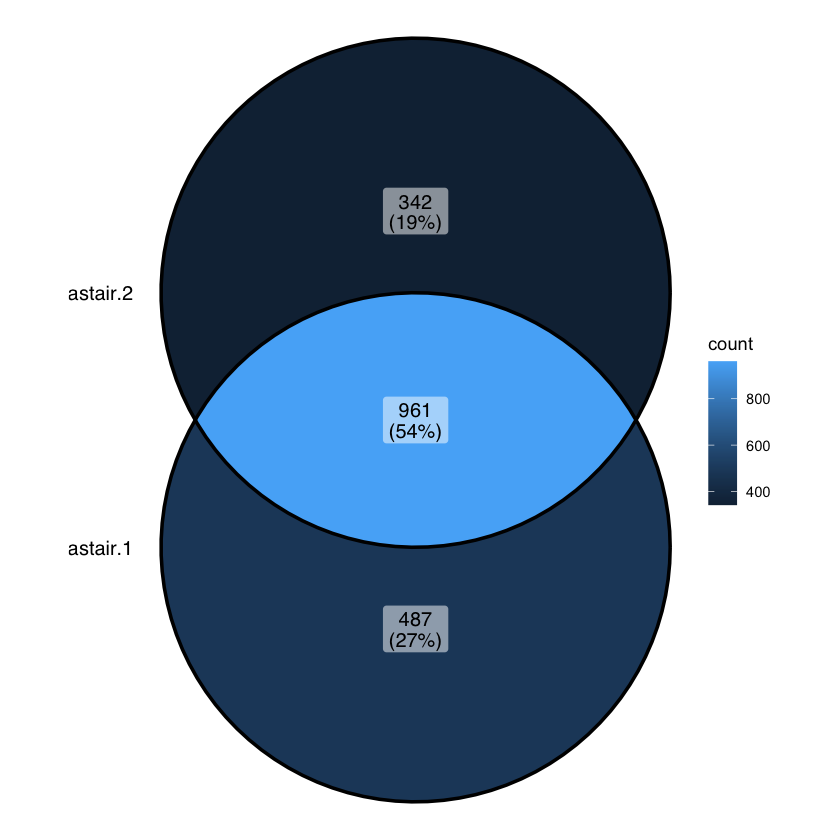

In [40]:
ggVennDiagram(list(rastair.1=paste(rastair.1$chr, rastair.1$start, sep="_"), rastair.2=paste(rastair.2$chr, rastair.2$start, sep="_")))

There's a slightly worrying number of positions where the two do not share any data. What are these positions?

In [46]:
rastair.1.exclusive <- rastair.2[rastair.1][is.na(mod), .(chr, start, end, beta_est=i.beta_est, mod=i.mod, unmod=i.unmod, snp=i.snp, no_snp=i.no_snp)]
dim(rastair.1.exclusive)

[1] 487   8

In [59]:
summary(rastair.1.exclusive$mod)
summary(rastair.1.exclusive$unmod)
summary(rastair.1.exclusive$unmod==0 & rastair.1.exclusive$mod==0)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
   1.00    8.00   11.00   10.76   13.00   23.00 

   Mode   FALSE 
logical     487 

Ok, so these are still all positions where there is coverage but no evidence for modification - this needs fixing.

What about the inverse, ie positions that are exclusive to rastair.2?

In [52]:
rastair.2.exclusive <- rastair.1[rastair.2][is.na(mod), .(chr, start, end, beta_est=i.beta_est, mod=i.mod, unmod=i.unmod, snp=i.snp, no_snp=i.no_snp)]
dim(rastair.2.exclusive)

[1] 342   8

In [58]:
summary(rastair.2.exclusive$mod)
summary(rastair.2.exclusive$unmod)
summary(rastair.2.exclusive$unmod==0 & rastair.2.exclusive$mod==0)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
      0       0       0       0       0       0 

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max. 
  0.000   0.000   0.000   3.094   7.000  19.000 

   Mode   FALSE    TRUE 
logical      98     244 

so 244 of these positions are those where there's no data at all to make a methylation call, ie neither `mod` nor `unmod`. It's strange though that some of these get reported in rastair2, but not others?

Also, what are the 98 positions where there's evidence for mod/unmod but no call in rastair 1?

In [84]:
# Annotate with genome sequence in context
genome <- import(params$test_fasta)
sequences <- mapply(function(chr, pos) {
    as.character(subseq(genome[[chr]], start=pos, end=pos+2))
}, rastair.2.exclusive$chr, rastair.2.exclusive$start)
rastair.2.exclusive[, context := sequences]

# How often is the position a "CG"?
rastair.2.exclusive[, .N, by=substr(context, 1, 2)][order(N, decreasing=TRUE)]
rastair.2.exclusive[, .N, by=substr(context, 2, 3)][order(N, decreasing=TRUE)]

substr,N
<chr>,<int>
CT,114
CA,67
CC,50
GA,27
AA,21
TG,17
GG,16
AG,15
TA,5


substr,N
<chr>,<int>
AG,100
TG,52
GG,48
TC,40
TT,23
CC,18
CT,17
CA,15
AC,12


No CG - as I thought: they are all "de-novo" CpGs. We should somehow label those more clearly in the bed output.